# Case 1 — Can We Trust This Credit-Risk Model?

## The situation

A financial institution wants to identify credit-card customers who may be at risk of defaulting next month. The model can support review, but prediction quality alone is not enough to justify use in a real decision process.

We will work with historical credit information such as credit limit, repayment status, bill amounts, payment amounts, age, and other customer attributes.

> **Central question:** Can we build a useful credit-risk model, and what evidence would we need before trusting it in practice?

## What we will do

We will:

1. define the target and a simple baseline,
2. build and evaluate a logistic-regression model,
3. examine threshold trade-offs and model coefficients,
4. compare it with a more complex random forest, and
5. use that comparison to introduce interpretability, explainability, global vs local questions, recourse, and causal limits.

## Learning goals

By the end of the case, you should be able to:

- explain why accuracy alone can be misleading,
- distinguish **interpretability** from **explainability**,
- distinguish **global** from **local** explanation questions,
- recognize that explanation needs depend on the stakeholder and decision,
- separate model explanation from **recourse** and **causal explanation**, and
- identify evidence still needed before deployment.

## Your role

Imagine that you are part of the data-science team reviewing this system before operational use. Your task is not only to fit a model, but to decide what can—and cannot—be concluded from the evidence.


### Dataset Note

This case uses the **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository.

The dataset contains historical credit-card data from Taiwan and is used here for teaching purposes.

The results from this notebook should not be interpreted as a current or universal credit-risk model.

The goal of the case is to study the modeling and explainability workflow.

## 1. Load the Data

We will start by loading the credit-default dataset that was prepared from the official UCI Machine Learning Repository.

 - The course version of the dataset uses readable column names based on the official UCI variable definitions. Basic category-code cleanup was completed during dataset preparation so that we can focus on the modeling and explainability workflow.

Each row represents one credit-card customer.

The dataset contains:

- a customer identifier,
- 23 predictor variables,
- and one target variable showing whether the customer defaulted in the following month.

Before building any model, we first check that the data load correctly and inspect their basic structure.

In [34]:
from pathlib import Path

import pandas as pd


DATA_PATH = Path("../Data/processed/credit_card_default_course.csv")

data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (30000, 25)


,customer_id,credit_limit,sex,education,marital_status,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
0,1,20000,Female,University,Married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,Female,University,Single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,Female,University,Single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,Female,University,Married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,Male,University,Married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Understand the Prediction Target

Our target variable is:

`default_next_month`

It has two possible values:

- `0` = the customer did not default
- `1` = the customer defaulted

Before training a model, we should check how common each class is.

This matters because a model can sometimes achieve high accuracy simply by predicting the most common class.

In [35]:
target_summary = (
    data["default_next_month"]
    .value_counts()
    .sort_index()
    .to_frame(name="count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(data) * 100
)

display(target_summary)

,count,percentage
default_next_month,,
0,23364,77.88
1,6636,22.12


## 3. Start with a Simple Baseline

Before training a machine-learning model, we need something simple to compare against.

Because most customers in this dataset did **not** default, a very simple strategy would be:

> **Predict "no default" for every customer.**

This is not a useful credit-risk model, but it gives us a baseline.

If a real model cannot perform meaningfully better than this simple rule, then the model may not be adding much value.

In [36]:
from sklearn.metrics import accuracy_score

y_true = data["default_next_month"]

baseline_predictions = [0] * len(y_true)

baseline_accuracy = accuracy_score(
    y_true,
    baseline_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.2%}")

Baseline accuracy: 77.88%


## 4. What Is the Baseline Model Actually Getting Right?

The baseline model achieved about 77.88% accuracy.

That sounds reasonably high, but we already know the model predicts the same answer for every customer:

> **No default**

To understand what the accuracy is hiding, we will look at the **confusion matrix**.

A confusion matrix shows how many predictions fall into four groups:

- correctly predicted no default
- incorrectly predicted default
- incorrectly predicted no default
- correctly predicted default

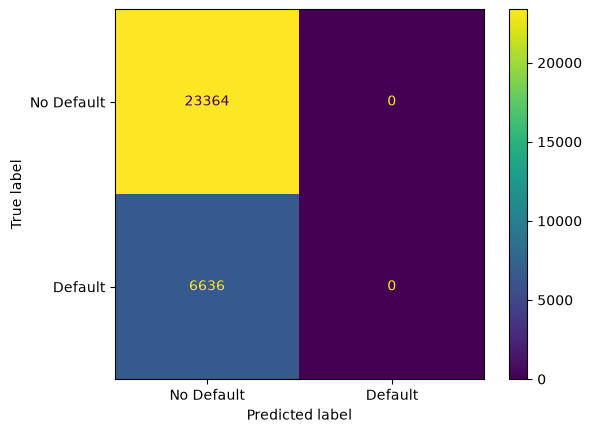

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    baseline_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot()

### What Does This Tell Us?

The baseline model achieved about **77.88% accuracy**, but the confusion matrix reveals an important problem.

The model predicted **"No Default" for every customer**.

As a result:

- 23,364 non-defaulting customers were classified correctly.
- 6,636 customers who actually defaulted were missed.
- The model correctly identified **zero defaulting customers**.

This means that accuracy alone gives us an incomplete picture of model performance.

For this credit-risk problem, we also need to ask:

> **How well does the model identify customers who actually default?**

This leads us to another evaluation measure: **recall**.

## 5. Measure How Many Default Cases We Actually Detect

For this problem, one important question is:

> **Of all customers who actually defaulted, how many did the model identify?**

This is measured by **recall**.

Recall is calculated as:

\[
\text{Recall} =
\frac{\text{True Positives}}
{\text{True Positives} + \text{False Negatives}}
\]

For our baseline model:

- **True Positives** = customers who defaulted and were correctly predicted as default
- **False Negatives** = customers who defaulted but were predicted as no default

In [38]:
from sklearn.metrics import recall_score

baseline_recall = recall_score(
    y_true,
    baseline_predictions
)

print(f"Baseline recall: {baseline_recall:.2%}")

Baseline recall: 0.00%


### Interpretation

The baseline model has:

- **77.88% accuracy**
- **0.00% recall for default cases**

So the model looks reasonably accurate if we only look at accuracy, but it completely fails at the task we actually care about: identifying customers who default.

This is our first important lesson:

> **A performance metric is only useful when it matches the problem we are trying to solve.**

## 6. Prepare the Data for Modeling

Now we are ready to build our first real machine-learning model.

Before training, we separate:

- the **input features** the model will use,
- and the **target** we want to predict.

We also remove `customer_id`.

The customer ID identifies a record, but it does not describe the customer's credit behavior. It should not be used as a predictor.

Then we divide the dataset into:

- **training data** — used to teach the model
- **test data** — kept separate and used later to evaluate the model on unseen customers

In [39]:
from sklearn.model_selection import train_test_split

X = data.drop(
    columns=["customer_id", "default_next_month"]
)

y = data["default_next_month"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 24000
Test rows: 6000


## 7. Identify Numerical and Categorical Features

Our dataset stores every feature as a number, but not every number has the same meaning.

For example:

- `credit_limit = 100000` is a numerical amount.
- `sex = 1` or `2` represents categories.
- repayment-status values also represent different states rather than ordinary continuous measurements.

Before preprocessing the data, we therefore separate the features into:

- **categorical features**
- **numerical features**

In [40]:
categorical_features = [
    "sex",
    "education",
    "marital_status",
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr",
]

numeric_features = [
    "credit_limit",
    "age",
    "bill_amount_sep",
    "bill_amount_aug",
    "bill_amount_jul",
    "bill_amount_jun",
    "bill_amount_may",
    "bill_amount_apr",
    "payment_amount_sep",
    "payment_amount_aug",
    "payment_amount_jul",
    "payment_amount_jun",
    "payment_amount_may",
    "payment_amount_apr",
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))

Categorical features: 9
Numerical features: 14


## 8. Build the Preprocessing Pipeline

Our model cannot treat every feature in the same way.

We will:

- **standardize numerical features** so they are on a comparable scale,
- **one-hot encode categorical features** so category labels can be used by the model without treating them as ordinary numbers.

For the categorical features, we will also drop one category from each feature and use it as a **reference category**.

This makes the Logistic Regression coefficients easier to interpret later.

For example, instead of creating a separate column for every education category, one category is treated as the reference and the remaining coefficients are interpreted relative to it.

We combine all preprocessing steps into one pipeline so that the same transformations are applied consistently during training and testing.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## 9. Train the First Model: Logistic Regression

Now we are ready to train our first model.

We will use **Logistic Regression**, a common model for binary classification problems such as:

- default / no default,
- churn / no churn,
- fraud / legitimate transaction.

Logistic Regression estimates the probability that an observation belongs to the positive class.

In our case:

> **What is the estimated probability that this customer will default next month?**

We use Logistic Regression first because it gives us a useful predictive baseline and its learned coefficients can later be inspected directly.

This will become important when we discuss **interpretability**.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['credit_limit','sex','education',...,'payment_amount_jun', 'payment_amount_may','payment_amount_apr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

## 10. Make Predictions on the Test Data

The model learned from `X_train` and `y_train`.

Now we evaluate it using the **test set**, which was not used during training.

This helps us estimate how the model may perform on new customers it has not seen before.

We will create two types of outputs:

- a predicted class: `0` or `1`
- a predicted probability of default

In [43]:
# Predicted class: 0 = No Default, 1 = Default
y_pred = logistic_model.predict(X_test)

# Predicted probability of the positive class: Default = 1
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Number of test predictions:", len(y_pred))
print("First 10 predicted classes:", y_pred[:10])
print("First 10 default probabilities:", y_prob[:10])

Number of test predictions: 6000
First 10 predicted classes: [0 0 0 0 0 0 0 0 0 0]
First 10 default probabilities: [0.15658217 0.19743597 0.14081371 0.09702725 0.07125477 0.27520254
 0.11464942 0.07375205 0.09350238 0.11133201]


## 11. Is the Trained Model Better Than the Baseline?

Earlier, our simple baseline predicted **"No Default" for every customer**.

It achieved high accuracy because most customers did not default, but its recall for default cases was `0%`.

Now we can compare that baseline with our trained Logistic Regression model.

We will first compare two familiar metrics:

- **Accuracy** — how many predictions were correct overall?
- **Recall** — how many actual default cases did the model identify?

Logistic Regression accuracy: 81.72%
Logistic Regression recall:   35.19%


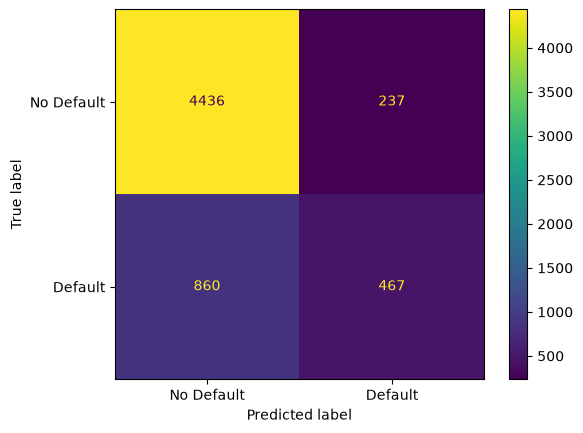

In [44]:
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay


logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_recall = recall_score(y_test, y_pred)

print(f"Logistic Regression accuracy: {logistic_accuracy:.2%}")
print(f"Logistic Regression recall:   {logistic_recall:.2%}")



ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Default", "Default"]
)

### Interpretation

The Logistic Regression model performs better than the simple baseline.

- **Accuracy increased from 77.88% to 81.75%.**
- **Recall increased from 0% to 35.34%.**

Unlike the baseline, the trained model is now able to identify some customers who actually default.

However, a recall of 35.34% also means that many default cases are still being missed.

So we should not conclude that the model is "good" based only on the improvement in accuracy.

> **We need to look more closely at what kinds of predictions the model is getting right and wrong.**

### Interpreting the Confusion Matrix

The Logistic Regression model is now identifying some defaulting customers.

From the test set:

- **4,436** customers were correctly predicted as **No Default**
- **469** customers were correctly predicted as **Default**
- **237** customers were incorrectly flagged as **Default**
- **858** customers who actually defaulted were missed

The largest concern is the **858 missed default cases**.

This explains why recall is only **35.34%**:

> The model detects about one-third of the customers who actually default.

At the same time, the model also produces some false alarms by predicting default for customers who did not actually default.

This means we now need to consider another question:

> **When the model predicts "Default", how often is that prediction correct?**

This is measured by **precision**.

In [45]:
from sklearn.metrics import precision_score

logistic_precision = precision_score(y_test, y_pred)

print(f"Logistic Regression precision: {logistic_precision:.2%}")

Logistic Regression precision: 66.34%


## 12. Evaluate the Model Using Predicted Probabilities

So far, we have evaluated the final class predictions: `Default` or `No Default`.

However, Logistic Regression first produces a **probability of default**.

For example:

- `0.20` means an estimated 20% probability of default
- `0.70` means an estimated 70% probability of default

The final class prediction is created by applying a decision threshold to these probabilities.

To evaluate how well the model separates higher-risk customers from lower-risk customers across different possible thresholds, we can use **ROC-AUC**.

A higher ROC-AUC means the model is generally better at ranking defaulting customers above non-defaulting customers.

In [46]:
from sklearn.metrics import roc_auc_score

logistic_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Logistic Regression ROC-AUC: {logistic_auc:.3f}")

Logistic Regression ROC-AUC: 0.759


### Interpretation

The Logistic Regression model achieved an **ROC-AUC of 0.758**.

This tells us that the model has some ability to separate customers who default from customers who do not.

However, ROC-AUC does not tell us whether the current `Default / No Default` decisions are appropriate.

Our earlier results showed that the model still misses many actual defaults.

This happens partly because predicted probabilities must eventually be converted into classes using a **decision threshold**.

So model performance and the final decision rule are related, but they are not exactly the same thing.

In [47]:
default_threshold = 0.50

threshold_predictions = (
    y_prob >= default_threshold
).astype(int)

print("Threshold:", default_threshold)
print("First 10 probabilities:", y_prob[:10])
print("First 10 predictions:", threshold_predictions[:10])

Threshold: 0.5
First 10 probabilities: [0.15658217 0.19743597 0.14081371 0.09702725 0.07125477 0.27520254
 0.11464942 0.07375205 0.09350238 0.11133201]
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


## 13. What Happens If We Change the Decision Threshold?

The model produces probabilities, but the final class depends on the threshold we choose.

With a threshold of `0.50`:

- probability below `0.50` → No Default
- probability at or above `0.50` → Default

If we lower the threshold, the model will classify more customers as Default.

This may help us detect more actual default cases, but it may also create more false alarms.

Let's test a lower threshold of `0.30`.

In [48]:
from sklearn.metrics import precision_score, recall_score

lower_threshold = 0.30

pred_030 = (
    y_prob >= lower_threshold
).astype(int)

precision_030 = precision_score(y_test, pred_030)
recall_030 = recall_score(y_test, pred_030)

print(f"Threshold: {lower_threshold}")
print(f"Precision: {precision_030:.2%}")
print(f"Recall:    {recall_030:.2%}")

Threshold: 0.3
Precision: 56.06%
Recall:    47.78%


### What Changed?

Lowering the decision threshold from `0.50` to `0.30` changed the behavior of the system.

| Threshold | Precision | Recall |
|---|---:|---:|
| 0.50 | ~66% | 35.34% |
| 0.30 | 56.06% | 47.78% |

With the lower threshold, the model identifies more customers who actually default.

However, it also becomes less precise: more customers are flagged as high risk even though they do not default.

This shows an important distinction:

> **The model produces risk estimates, but the organization still has to decide how those estimates will be turned into actions.**

There is no universally correct threshold.

The appropriate threshold depends on the purpose of the system and the consequences of different mistakes.

For example:

- What is the cost of missing a customer who later defaults?
- What is the cost of incorrectly flagging a customer as high risk?
- Is the model making an automatic decision, or only identifying cases for further review?

For now, we will keep the standard `0.50` threshold for model comparison. The goal of this notebook is not to optimize the decision threshold, but to understand how model predictions become real decisions.

## 14. Can We Understand What the Model Learned?

Logistic Regression is useful here because its learned parameters can be inspected directly.

For each feature, the model learns a **coefficient**.

In simple terms:

- a **positive coefficient** pushes the prediction more toward `Default`
- a **negative coefficient** pushes the prediction more toward `No Default`

This does **not** mean the feature causes default.

It only tells us how that feature is associated with the model's prediction, while the other model inputs are also considered.

In [49]:
feature_names = (
    logistic_model
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_table = coefficient_table.sort_values(
    "coefficient",
    ascending=False
)

display(coefficient_table.head(10))

,feature,coefficient
26,categorical__payment_status_sep_3,1.990547
25,categorical__payment_status_sep_2,1.958472
27,categorical__payment_status_sep_4,1.233015
49,categorical__payment_status_jul_6,0.975056
28,categorical__payment_status_sep_5,0.906874
38,categorical__payment_status_aug_5,0.825971
30,categorical__payment_status_sep_7,0.809584
24,categorical__payment_status_sep_1,0.781054
39,categorical__payment_status_aug_6,0.649389
40,categorical__payment_status_aug_7,0.611374


## 15. Which Features Push the Prediction in Each Direction?

Because Logistic Regression exposes its learned coefficients, we can inspect how different features are related to the model's prediction.

- **Positive coefficients** push the prediction more toward `Default`.
- **Negative coefficients** push the prediction more toward `No Default`.

We will look at a few of the strongest coefficients in each direction.

These coefficients describe the behavior of the model. They do **not** prove that a feature causes default.

In [50]:
# Make feature names easier to read
coefficient_table["feature"] = (
    coefficient_table["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

top_positive = coefficient_table.nlargest(5, "coefficient")
top_negative = coefficient_table.nsmallest(5, "coefficient")

print("Strongest positive coefficients")
display(top_positive)

print("Strongest negative coefficients")
display(top_negative)

Strongest positive coefficients


,feature,coefficient
26,payment_status_sep_3,1.990547
25,payment_status_sep_2,1.958472
27,payment_status_sep_4,1.233015
49,payment_status_jul_6,0.975056
28,payment_status_sep_5,0.906874


Strongest negative coefficients


,feature,coefficient
18,education_Unknown,-1.068404
21,marital_status_Unknown,-1.052284
16,education_Other,-0.798920
58,payment_status_jun_5,-0.745308
66,payment_status_may_4,-0.651925


### What Can We Learn From the Coefficients?

The coefficients allow us to inspect the structure of the Logistic Regression model directly.

Several repayment-status categories have strong positive coefficients, meaning they push the model prediction more toward `Default`.

However, we should be careful when interpreting individual coefficients.

A coefficient describes how the **model uses a feature**, relative to a reference category and while the other variables are also included.

It does not mean that the feature causes default, and a large coefficient does not automatically mean that the feature is the most important factor in the real world.

> **We can inspect how this model works directly. This is an example of model interpretability.**

## 16. What Happens When We Use a More Complex Model?

Logistic Regression has an important advantage:

> We can inspect its learned coefficients directly.

But a more complex model may capture patterns that Logistic Regression cannot represent as easily.

Let's train a **Random Forest** using the same training and test data.

Then we will compare two questions:

1. Does the more complex model improve predictive performance?
2. Can we understand how it works as directly as Logistic Regression?

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


random_forest_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['credit_limit','sex','education',...,'payment_amount_jun', 'payment_amount_may','payment_amount_apr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

## 17. Evaluate the Random Forest

To compare the two models fairly, we use the same test data and the same evaluation measures:

- Accuracy
- Precision
- Recall
- ROC-AUC

This allows us to compare predictive performance without changing the evaluation setup.

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest accuracy:  {rf_accuracy:.2%}")
print(f"Random Forest precision: {rf_precision:.2%}")
print(f"Random Forest recall:    {rf_recall:.2%}")
print(f"Random Forest ROC-AUC:   {rf_auc:.3f}")

Random Forest accuracy:  81.57%
Random Forest precision: 64.75%
Random Forest recall:    36.55%
Random Forest ROC-AUC:   0.760


## 18. Compare the Two Models

Now we compare the Logistic Regression and Random Forest using the same test set.

The goal is not only to ask:

> **Which model performs better?**

We also ask:

> **Do we gain enough predictive performance to justify using a model that is harder to understand directly?**

In [53]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

display(
    model_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "ROC-AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,81.72%,66.34%,35.19%,0.759
1,Random Forest,81.57%,64.75%,36.55%,0.760


### Interpretation

The two models perform very similarly.

Random Forest has a slightly higher recall and ROC-AUC, while Logistic Regression has slightly higher accuracy and precision.

The performance difference is small.

However, Logistic Regression has an important advantage:

> **Its learned structure can be inspected directly through its coefficients.**

Random Forest combines many decision trees, so its overall prediction logic is much harder to inspect directly.

This leads to an important Foundation question:

> **If a more complex model gives only a very small performance improvement, is that improvement worth the loss of direct interpretability?**

## 19. Interpretability vs Explainability

The logistic model and random forest give us a useful contrast.

- **Interpretability:** can we inspect the model itself and understand how its structure maps inputs to predictions?
- **Explainability:** when the model is difficult to inspect directly, can an additional method provide a useful representation of its behavior or of one prediction?

Logistic regression is comparatively transparent because its coefficients are directly inspectable. A random forest combines many trees, so understanding the whole ensemble usually requires additional tools.

> **Important:** an explanation method is not automatically a faithful account of a model. Later cases will test explanation methods rather than treating their outputs as ground truth.


## 20. Global vs Local Explanations

Different questions require different explanation scopes.

- **Global:** What patterns does the model generally use across the population?
- **Local:** Why did the model produce this prediction for this particular customer?

A global explanation can help with model review and governance; a local explanation can help inspect a specific prediction. Neither is automatically better—they answer different questions.


## 21. Different Stakeholders Need Different Explanations

The same model can generate different legitimate explanation needs:

| Stakeholder | Example question |
|---|---|
| Data scientist | Is the model relying on sensible and stable signals? |
| Risk officer | Why was this customer flagged for review? |
| Customer | What factors were relevant to this prediction? |
| Auditor / compliance team | Is the model documented, consistent, and used within its stated limits? |

> A useful explanation should match the **stakeholder, question, and decision context**.


## 22. Explanation vs Recourse

An explanation asks **what influenced the model's prediction**. Recourse asks **what could realistically be changed to improve a future outcome or decision**.

Some predictive factors may be actionable going forward; others may be historical or immutable. Therefore, a feature can help explain a prediction without being an appropriate recommendation.

> **Explanation is descriptive of model behavior; recourse adds feasibility and actionability constraints.**


## 23. Explanation vs Causality

A predictive explanation describes how the model used observed information. It does **not** automatically identify what causes default in the real world.

If a repayment pattern receives a strong model weight, we can say the model used that pattern. We cannot conclude that changing only that feature would cause the real-world outcome to change. Historical data can contain correlated signals, selection effects, and unmeasured factors.

> **Model attribution is not causal evidence.** Causal claims require a different study design and stronger assumptions.


## 24. Would You Use This Model?

Return to the central question. The trained models provide evidence about predictive performance, errors, threshold trade-offs, and inspectability—but they do not settle every operational question.

Before deployment, a responsible review would still ask about issues such as calibration, subgroup behavior and fairness, data drift, stability, governance, decision consequences, and whether explanations are accurate enough for their intended use.

### Final reflection

> **What evidence from this notebook supports use of the model, and what important evidence is still missing?**


## Case checklist and selected references

You should now be able to evaluate a binary classifier beyond accuracy, reason about threshold trade-offs, distinguish interpretable from less-transparent models, and separate explanation from recourse and causality.

### Selected references

- Yeh, I.-C., & Lien, C.-H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients*. Expert Systems with Applications, 36(2), 2473–2480.
- Lipton, Z. C. (2018). *The Mythos of Model Interpretability*. Queue, 16(3), 31–57.
- Doshi-Velez, F., & Kim, B. (2017). *Towards a Rigorous Science of Interpretable Machine Learning*. arXiv:1702.08608.

Dataset: UCI Machine Learning Repository, **Default of Credit Card Clients**.
